# Survival analysis

**This notebook analyzes survival in patients with advanced urothelial cancer receiving first-line pembrolizumab versus those receiving carboplatin-based or cisplatin-based chemotherapy in cluster 0 (see clustering_pembro_carbo.ipynb).** 

In [1]:
import numpy as np
import pandas as pd

from flatiron_cleaner import DataProcessorUrothelial

from iptw_survival import IPTWSurvivalEstimator

import matplotlib.pyplot as plt

## Import data

### Cleaned data

In [2]:
dtype_map = pd.read_csv('../outputs/final_df_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
df = pd.read_csv('../outputs/final_df.csv', dtype = dtype_map)

In [3]:
df.head(3)

,PatientID,DiseaseGrade,SmokingStatus,Surgery,GroupStage_mod,TStage_mod,NStage_mod,MStage_mod,SurgeryType_mod,days_diagnosis_to_adv,...,drug_abuse,psychoses,depression,van_walraven_score,lymph_met,thoracic_met,liver_met,bone_met,other_gi_met,other_combined_met
0,F0016E985D839,High grade (G2/G3/G4),1,1,IV,T3,N1,M0,upper,0.0,...,0,0,0,4,0,0,0,0,0,0
1,F001E5D4C6FA0,Low grade (G1),1,1,unknown,T1,unknown,unknown,bladder,274.0,...,0,0,0,<NA>,0,0,0,0,0,0
2,F0025BA658AE1,High grade (G2/G3/G4),1,0,unknown,T3,unknown,M0,NaN,621.0,...,0,0,0,4,0,0,0,0,0,0


In [4]:
df.shape

(6461, 149)

### Mortality data

In [5]:
pembro_carbo_df = pd.read_csv('../outputs/full_cohort_carbo.csv')

In [6]:
pembro_carbo_df.head(1)

,PatientID,LineName,StartDate
0,F5AAF96C85477,Pembrolizumab,2021-07-08


In [7]:
pembro_carbo_df.shape

(3712, 3)

In [8]:
processor = DataProcessorUrothelial()

# Process Enhanced_Mortality_V2.csv and use visit, telemedicine, biomarkers, oral, and progression data to determine censoring date 
mortality_df = processor.process_mortality(file_path = '../data/Enhanced_Mortality_V2.csv',
                                           index_date_df = pembro_carbo_df, 
                                           index_date_column = 'StartDate',
                                           visit_path = '../data/Visit.csv', 
                                           telemedicine_path = '../data/Telemedicine.csv', 
                                           biomarkers_path = '../data/Enhanced_AdvUrothelialBiomarkers.csv', 
                                           oral_path = '../data/Enhanced_AdvUrothelial_Orals.csv',
                                           progression_path = '../data/Enhanced_AdvUrothelial_Progression.csv',
                                           drop_dates = False)

2025-05-16 22:09:14,838 - INFO - Successfully read Enhanced_Mortality_V2.csv file with shape: (9040, 2) and unique PatientIDs: 9040
2025-05-16 22:09:14,848 - INFO - Successfully merged Enhanced_Mortality_V2.csv df with index_date_df resulting in shape: (3712, 3) and unique PatientIDs: 3712
2025-05-16 22:09:15,256 - INFO - The following columns ['last_visit_date', 'last_biomarker_date', 'last_oral_date', 'last_progression_date'] are used to calculate the last EHR date
2025-05-16 22:09:15,261 - INFO - Successfully processed Enhanced_Mortality_V2.csv file with final shape: (3712, 6) and unique PatientIDs: 3712. There are 0 out of 3712 patients with missing duration values


In [9]:
mortality_df.head(1)

,PatientID,imported_StartDate,DateOfDeath,event,last_ehr_activity,duration
0,F5AAF96C85477,2021-07-08,NaT,0,2021-09-14,68.0


In [10]:
mortality_df.shape

(3712, 6)

In [11]:
mortality_df = pd.merge(mortality_df, pembro_carbo_df[['PatientID', 'LineName']], on = 'PatientID', how = 'left')

In [12]:
mortality_df.shape

(3712, 7)

In [13]:
mortality_df['treatment'] = (mortality_df['LineName'] == 'Pembrolizumab').astype(int)

In [14]:
mortality_df.treatment.value_counts(dropna = False)

treatment
0    2226
1    1486
Name: count, dtype: int64

### Insurance and SES data

In [15]:
insurance_ses_df = pd.read_csv('../outputs/insurance_ses_df.csv')

In [16]:
insurance_ses_df.head(3)

,PatientID,commercial,medicaid,medicare,other_insurance,ses_mod
0,F5AAF96C85477,0,0,1,0,1 - Lowest SES
1,F788831A66E9A,1,0,1,0,1 - Lowest SES
2,F75847DF35E43,1,0,0,1,2-4


In [17]:
insurance_ses_df.shape

(6461, 6)

In [18]:
insurance_ses_df['ses_mod'] = insurance_ses_df['ses_mod'].astype('category')

### Clustering data 

In [19]:
cluster_df = pd.read_csv('../outputs/cluster_pembro_carbo_df.csv')

In [20]:
cluster_df.cluster.value_counts()

cluster
0    1531
5     822
4     665
1     307
3     204
2     177
Name: count, dtype: int64

In [21]:
cluster_df.shape

(3706, 2)

### Merge

In [22]:
cluster_df = cluster_df.query('cluster == 0')

In [23]:
cluster_df = pd.merge(cluster_df, df, on = 'PatientID', how = 'left')

In [24]:
cluster_df = pd.merge(cluster_df, mortality_df[['PatientID', 'treatment', 'event', 'duration']], on = 'PatientID', how = 'left')

In [25]:
cluster_df = pd.merge(cluster_df, insurance_ses_df, on = 'PatientID', how = 'left')

In [26]:
cluster_df.shape

(1531, 158)

## Survival analysis 

### Preprocessing

In [27]:
(
    cluster_df.groupby('treatment')['event']
    .apply(lambda x: (x == 0).mean())
)

treatment
0    0.244218
1    0.322222
Name: event, dtype: float64

In [28]:
cluster_df.groupby(['adv_diagnosis_year', 'treatment']).size().unstack(fill_value=0)

/var/folders/lr/vkkcj_s12115sxc05ly3mshh0000gn/T/ipykernel_44283/3518407394.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_df.groupby(['adv_diagnosis_year', 'treatment']).size().unstack(fill_value=0)


treatment,0,1
adv_diagnosis_year,,
2011,60,0
2012,86,0
2013,81,2
2014,91,2
2015,103,3
2016,113,5
2017,101,41
2018,74,53
2019,77,86


In [29]:
cluster_df['adv_diagnosis_year'] = cluster_df['adv_diagnosis_year'].astype(int)
cluster_df['before_2020'] = np.where(cluster_df['adv_diagnosis_year'] < 2020, 1, 0)

### IPTW

In [30]:
estimator = IPTWSurvivalEstimator()

In [31]:
# We apply stabilized IPTW and clip propensity scores to the [0.01, 0.99] range to reduce the influence of extreme values
estimator.fit(df = cluster_df,
              treatment_col = 'treatment',
              cat_var = ['GroupStage_mod', 'ecog_index', 'ses_mod', 'PDL1_status'],
              cont_var = ['days_diagnosis_to_adv', 'age', 'weight_index', 'percent_change_weight', 'albumin', 'creatinine', 'total_bilirubin', 'van_walraven_score'],
              binary_var = ['Surgery', 'opioid', 'commercial', 'medicaid', 'before_2020'],
              lr_kwargs = {
                  'class_weight': 'balanced',
                  'solver': 'lbfgs',
                  'penalty': 'l2',
                  'max_iter': 1000,
                  'random_state': 42
              },
              clip_bounds = (0.01, 0.99),
              stabilized = True,)

In [32]:
iptw_df = estimator.transform()

In [33]:
ps_fig = estimator.propensity_score_plot(bins = 30)

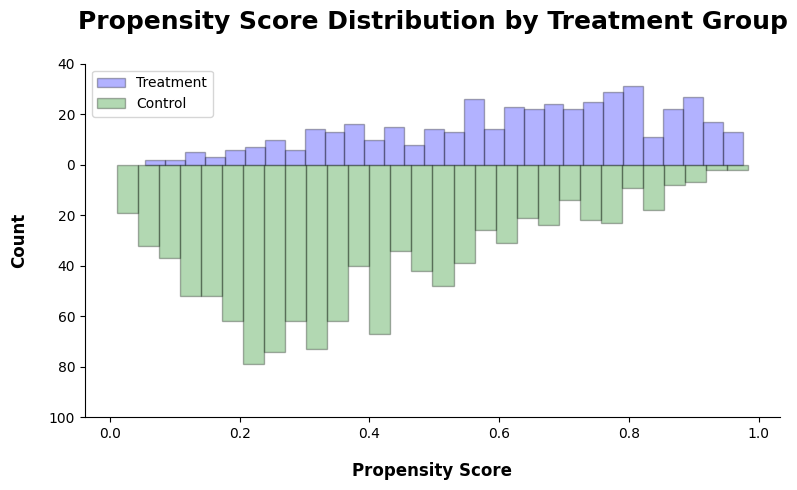

In [34]:
ps_fig

In [35]:
smd_df, smd_fig = estimator.standardized_mean_differences(return_fig = True)

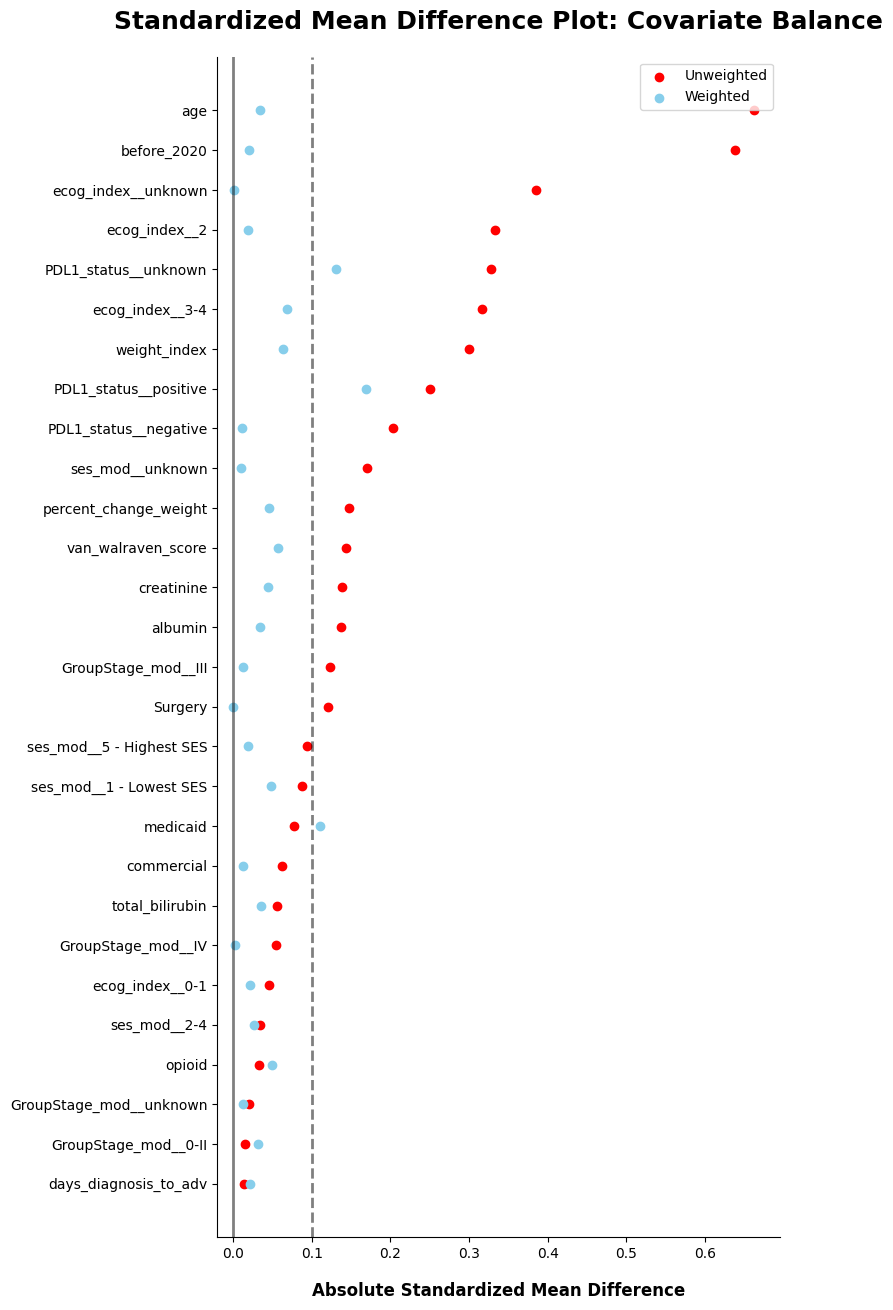

In [36]:
smd_fig

In [37]:
# Convert days to month
iptw_df['duration'] = iptw_df['duration']/30

In [38]:
km_confidence_intervals_df = estimator.km_confidence_intervals(df = iptw_df,
                                                               duration_col = 'duration',
                                                               event_col = 'event',
                                                               weight_col = 'iptw',
                                                               n_bootstrap = 1000,
                                                               random_state = 42)

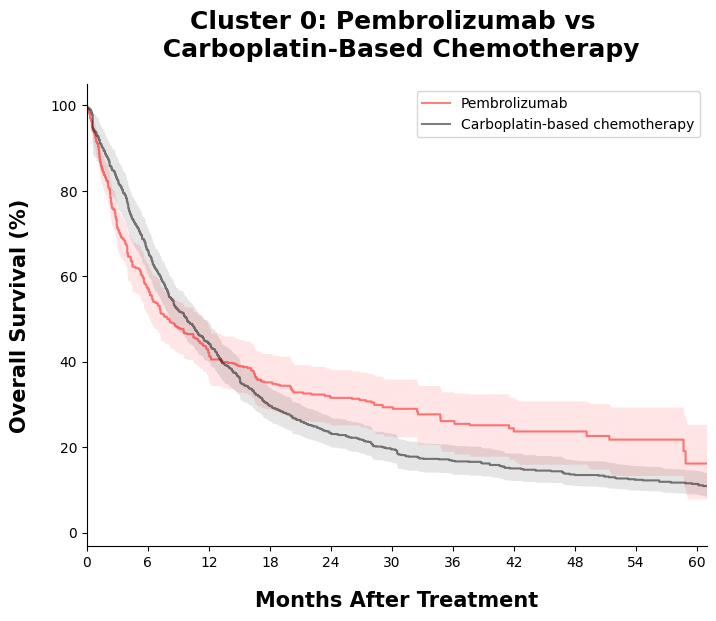

In [46]:
fig = plt.figure(figsize=(8, 6))

# Pembrolizumab arm
# Estimate
plt.step(km_confidence_intervals_df.time, 
         km_confidence_intervals_df.treatment_estimate * 100, 
         color = 'red', 
         alpha = 0.5,
         label = 'Pembrolizumab')

# 95% CI
plt.fill_between(km_confidence_intervals_df.time, 
                 km_confidence_intervals_df.treatment_lower_ci * 100, 
                 km_confidence_intervals_df.treatment_upper_ci * 100, 
                 facecolor = 'red', 
                 alpha = 0.1)

# Chemotherapy arm
# Estimate
plt.step(km_confidence_intervals_df.time, 
         km_confidence_intervals_df.control_estimate * 100, 
         color = 'black', 
         alpha = 0.5,
         label = 'Carboplatin-based chemotherapy')

# 95% CI
plt.fill_between(km_confidence_intervals_df.time, 
                 km_confidence_intervals_df.control_lower_ci * 100, 
                 km_confidence_intervals_df.control_upper_ci * 100, 
                 facecolor = 'black', 
                 alpha = 0.1)

plt.xticks(np.arange(0, 61, 6))
plt.xlim(0, 61)

plt.title('Cluster 0: Pembrolizumab vs \n Carboplatin-Based Chemotherapy', size = 18, weight = 'bold',  pad = 20)
plt.ylabel('Overall Survival (%)', size = 15, weight = 'bold', labelpad = 15)
plt.xlabel('Months After Treatment', size = 15, weight = 'bold', labelpad = 15)
plt.legend(prop = {'size': 10})

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../outputs/survival_pembro_carbo_cluster.pdf', format = 'pdf', bbox_inches = 'tight')

In [47]:
results = estimator.survival_metrics(df = iptw_df,
                                     duration_col = 'duration',
                                     event_col = 'event',
                                     weight_col = 'iptw',
                                     psurv_time_points = [36, 48],
                                     rmst_time_points = [36, 48],
                                     median_time = True,
                                     n_bootstrap = 1000,
                                     random_state = 42)

In [41]:
# Median results
print('Median Survival Results')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['treatment']['median'])} months')
print(f'Chemotherapy: {tuple(round(x, 1) for x in results['control']['median'])} months')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['median'])} months')

Median Survival Results
Pembrolizumab: (8.1, 6.2, 11.4) months
Chemotherapy: (9.9, 8.3, 11.6) months
Difference: (-1.7, -4.4, 1.9) months


In [42]:
# RMST results at 3 years
print('RMST Results at 3 Years')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['treatment']['rmst'][36])} months')
print(f'Chemotherapy: {tuple(round(x, 1) for x in results['control']['rmst'][36])} months')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][36])} months')

# RMST results at 4 years
print('')
print('RMST Results at 4 Years')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['treatment']['rmst'][48])} months')
print(f'Chemotherapy: {tuple(round(x, 1) for x in results['control']['rmst'][48])} months')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][48])} months')

RMST Results at 3 Years
Pembrolizumab: (15.3, 13.3, 17.3) months
Chemotherapy: (14.3, 13.1, 15.6) months
Difference: (1.0, -1.4, 3.3) months

RMST Results at 4 Years
Pembrolizumab: (18.2, 15.5, 20.9) months
Chemotherapy: (16.2, 14.7, 17.8) months
Difference: (2.1, -1.2, 5.2) months


In [48]:
# Probability of survival at 3 years
print('Probability of Survival at 3 Years')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][36])}')
print(f'Chemotherapy: {tuple(round(x, 3) for x in results['control']['survival_prob'][36])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][36])}')

# Probability of survival at 4 years
print('')
print('Probability of Survival at 4 Years')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][48])}')
print(f'Chemotherapy: {tuple(round(x, 3) for x in results['control']['survival_prob'][48])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][48])}')

Probability of Survival at 3 Years
Pembrolizumab: (0.261, 0.19, 0.329)
Chemotherapy: (0.168, 0.136, 0.204)
Difference: (0.093, 0.015, 0.168)

Probability of Survival at 4 Years
Pembrolizumab: (0.237, 0.159, 0.308)
Chemotherapy: (0.136, 0.11, 0.169)
Difference: (0.101, 0.019, 0.178)
